In [1]:
########################################################################
# Test code for TFRP
# Author : Sejong Oh
########################################################################

! pip install tf_keras_vis

import os

# Move to directory that has TFRP.
os.chdir('/content/drive/MyDrive/Colab Notebooks/TFRP_project/github_publish/')
import TFRP_v5 as TFRP

In [2]:
#######################################################################
# Load  model and test image
#######################################################################

## Load Model  -----------------------------------
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input,decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np

model = ResNet50(weights='imagenet', )

model_type = TFRP.check_model_type(model)
if model_type != "Sequential" and model_type != "Functional" :
    print ("Error. The model is broken")
else:
    print ("Model type :", model_type)

## Load Test image  -----------------------------------
image_path = '/content/drive/MyDrive/Colab Notebooks/TFRP_project/imagen_5/'

images = ["n01443537_goldfish.JPEG"]

org_imgs = np.zeros((1, 224, 224, 3)) # for org image
input_imgs = np.zeros((1, 224, 224, 3)) # for preprocessed image

# Single image prediction
img = image.load_img(image_path+images[0], target_size=(224, 224))
x = image.img_to_array(img)
org_imgs[0] = x.copy()
x = preprocess_input(x)
input_imgs[0] = x.copy()

# take top classes
preds = model.predict(org_imgs)
top_classes = np.argmax(preds, axis=1)
top_class_labels = decode_predictions(preds, top=1)

print("Top class label:", top_class_labels[0][0][1])
print("Top class probability:", preds[0][top_classes[0]])



Model type : Functional
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Top class label: goldfish
Top class probability: 0.85220563


In [3]:
#######################################################################
# Take TFRP relevance map
#######################################################################
import importlib
importlib.reload(TFRP)
if  model_type == "Sequential":
    TFRP_result = TFRP.get_relevance_map_sequential(model, input_imgs[0], top_classes[0])
elif model_type == "Functional":
    TFRP_result = TFRP.get_relevance_map_graph(model, input_imgs[0], top_classes[0])

print("Shape of TFRP_result :", TFRP_result.shape)

Shape of TFRP_result : (1, 224, 224, 3)


Original Image Size: 224x224


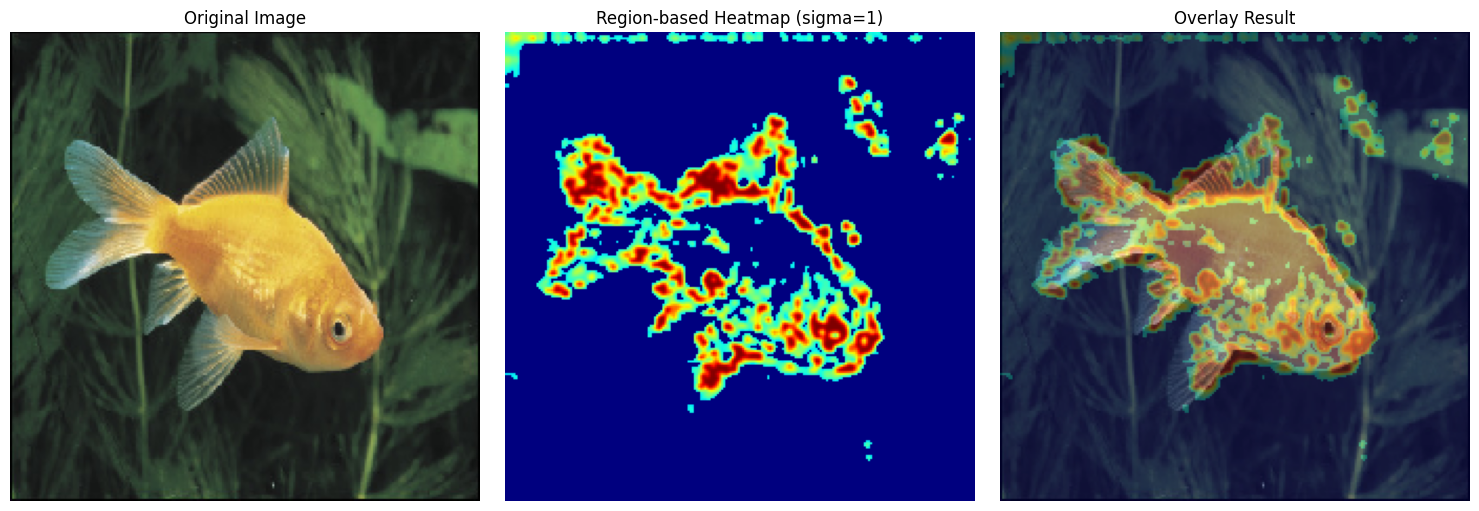

Original Image Size: 224x224


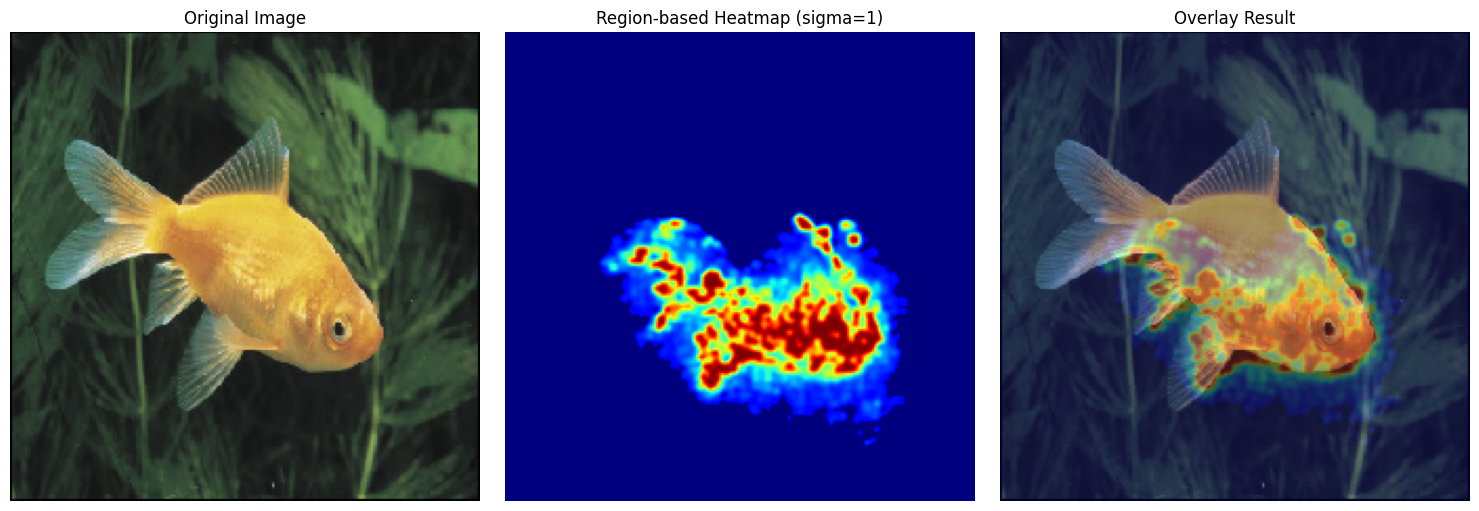

Original Image Size: 224x224
[Superpixel] Input Range: Min=0.0000, Max=0.3352


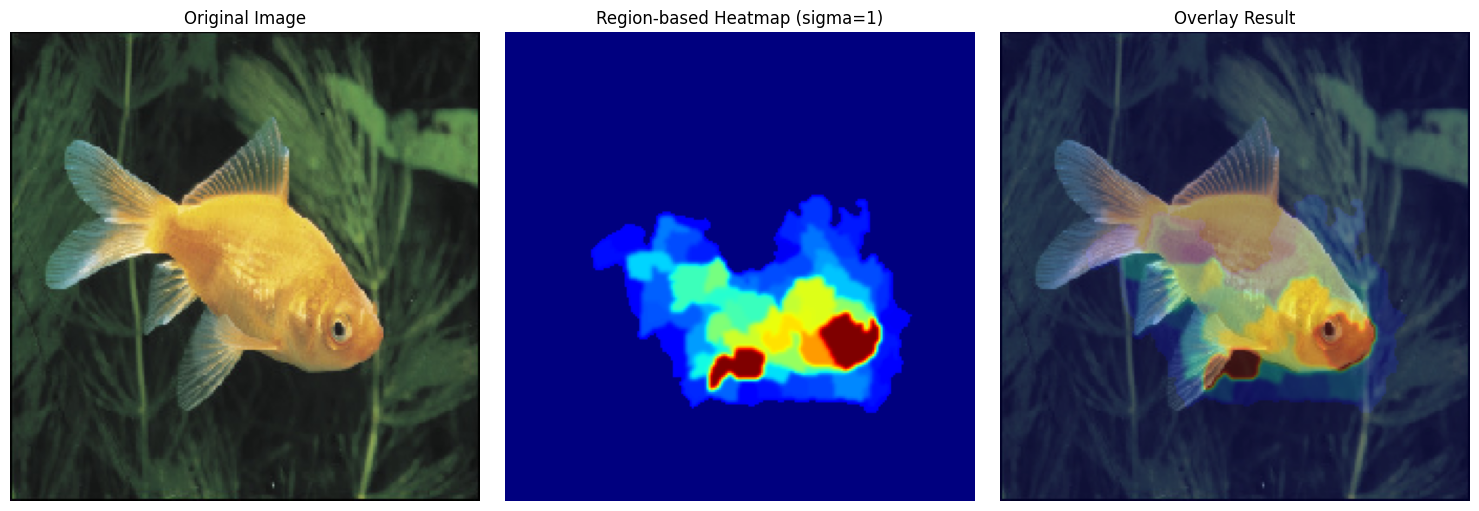

In [6]:
#######################################################################
# Visualize TFRP relevance map
#######################################################################

# TFRP relevance map (Apply minimal preprocessing)
res_norm, overlay = TFRP.visualize_TFRP_new(model, org_imgs[0], input_imgs[0], TFRP_result, top_classes[0], alpha=0.3, sigma=1, step=1)

# TFRP relevance map (Apply full preprocessing)
res_norm, overlay = TFRP.visualize_TFRP_new(model, org_imgs[0], input_imgs[0], TFRP_result, top_classes[0], alpha=0.3, sigma=1, segment_n=400, step=2)

# Superpixel applied TFRP relevance map
res_norm, overlay = TFRP.visualize_TFRP_new(model, org_imgs[0], input_imgs[0], TFRP_result, top_classes[0], alpha=0.3, sigma=1, segment_n=400, step=3)


